tensor([6.0259, 6.0820])
tensor([ 2.2908, 10.7640])
tensor([ 2.1092, 10.5011])
tensor([ 2.1092, 10.5011])
tensor([ 2.1092, 10.5011])
tensor([ 2.1092, 10.5011])
tensor([ 2.1092, 10.5011])
tensor([ 2.1092, 10.5011])
tensor([ 2.1092, 10.5011])
tensor([ 2.1092, 10.5011])
tensor([ 2.1092, 10.5011])
tensor([ 2.1092, 10.5011])
tensor([ 2.1092, 10.5011])
tensor([ 2.1092, 10.5011])
tensor([ 2.1092, 10.5011])
tensor([ 2.1092, 10.5011])
tensor([ 2.1092, 10.5011])
tensor([ 2.1092, 10.5011])
tensor([ 2.1092, 10.5011])
tensor([ 2.1092, 10.5011])
estimated rates: tensor([ 2.1092, 10.5011])


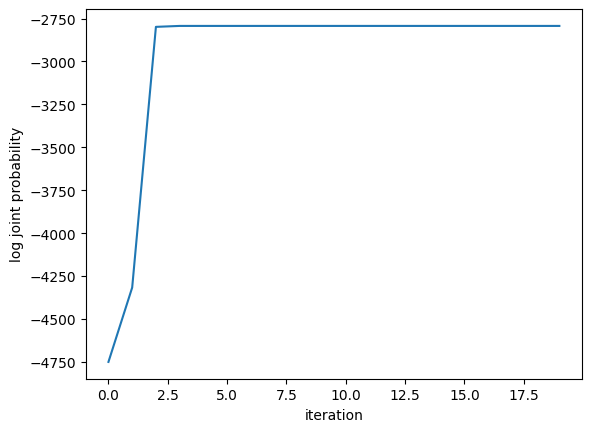

In [48]:
import matplotlib.pyplot as plt
import torch
from torch.distributions.poisson import Poisson
from torch.distributions.gamma import Gamma

def draw_data(pi, lambdas):
    """Draw data from a mixture of Poisson distributions.

    Args:
        pi: shape `(K,)` tensor of cluster probabilities
        lambdas: shape `(K,)` tensor of nonnegative rates for each cluster.
    
    Returns:
        data: shape `(N,)` tensor of counts
    """
    N = 1000
    K = pi.shape[0]
    assignments = torch.multinomial(pi, N, replacement=True)
    data = torch.poisson(lambdas[assignments])
    return data

def update_assignments(data, rates, probs):
    """Update the cluster assignments ($z$) given the data, rates, 
    and cluster probabilities.

    Args:
        data: shape `(N,)` tensor of counts
        rates: shape `(K,)` tensor of nonnegative rates for each cluster.
        probs: shape `(K,)` tensor of cluster probabilities
        
    Returns:
        assignments: shape `(N,)` tensor of integer cluster assignments
    """
    likelihood=Poisson(rates)
    log_lik=likelihood.log_prob(data[:,None])+torch.log(probs)
    assignments=torch.argmax(log_lik,axis=1)
    return assignments

def update_rates(data, assignments, shape=1.0, inv_scale=1.0):

    rates = []

    for k in range(assignments.max().item() + 1):

        posterior_shape = shape + data[assignments == k].sum()
        posterior_inv_scale = inv_scale + (assignments == k).sum()

        rate = (posterior_shape - 1) / posterior_inv_scale

        rates.append(rate)

    return torch.stack(rates)
    

def log_joint(data, assignments, rates, probs, shape=1.0, inv_scale=1.0):
    """_summary_

    Args:
        data: shape `(N,)` tensor of counts
        assignments: shape `(N,)` tensor of integer cluster assignments
        rates: shape `(K,)` tensor of updated rates for each cluster
        probs: shape `(K,)` tensor of cluster probabilities
        shape: shape (aka concentration) of gamma prior. Defaults to 1.0.
        inv_scale: inverse scale (aka rate) of gamma prior. Defaults to 1.0.
        
    Returns:
        lp: scalar log joint probability under the mixture model
    """

    # 1. log p(x | z, lambda)
    lp_data = Poisson(rates[assignments]).log_prob(data).sum()

    # 2. log p(z | pi)
    lp_assignments = torch.log(probs[assignments]).sum()

    # 3. log p(lambda)
    prior = Gamma(
        concentration=torch.as_tensor(shape, dtype=rates.dtype, device=rates.device),
        rate=torch.as_tensor(inv_scale, dtype=rates.dtype, device=rates.device)
    )
    lp_rates = prior.log_prob(rates).sum()

    # log p(x, z, lambda)
    lp = lp_data + lp_assignments + lp_rates

    return lp

data = draw_data(torch.tensor([0.5, 0.5]), torch.tensor([10.0, 2.0]))
# Run coordinate ascent for some number of iterations, starting
# with random cluster assignments
probs = torch.ones(2) / 2.0
assignments = torch.randint(0, 2, data.shape)
rates = 10 * torch.rand(2)

lps = []
for i in range(20):
    lps.append(log_joint(data, assignments, rates, probs))
    rates = update_rates(data, assignments)
    print(rates)
    assignments = update_assignments(data, rates, probs)
    
plt.plot(lps)
plt.xlabel("iteration")
plt.ylabel("log joint probability")

print("estimated rates:", rates)